# statistical Analysis 

In [3]:

import pandas as pd
import numpy as np
data={
    "Maths":[60,55,45,40,35],
    "science":[54,34,75,85,69],
    "English":[69,58,29,42,68]
    
}
df=pd.DataFrame(data)
print("Mean")
df.mean(axis=1)


Mean


0    61.000000
1    49.000000
2    49.666667
3    55.666667
4    57.333333
dtype: float64

In [6]:
print("Quantile")
print(df.quantile())
print("-----------------------------------------------------")
print("Correlation")
print(df.corr())

Quantile
-----------------------------------------------------
Correlation


,Maths,science,English
Maths,1.000000,-0.725522,0.268365
science,-0.725522,1.000000,-0.528235
English,0.268365,-0.528235,1.000000


In [ ]:
help()


Welcome to Python 3.8's help utility!

If this is your first time using Python, you should definitely check out
the tutorial on the Internet at https://docs.python.org/3.8/tutorial/.

Enter the name of any module, keyword, or topic to get help on writing
Python programs and using Python modules.  To quit this help utility and
return to the interpreter, just type "quit".

To get a list of available modules, keywords, symbols, or topics, type
"modules", "keywords", "symbols", or "topics".  Each module also comes
with a one-line summary of what it does; to list the modules whose name
or summary contain a given string such as "spam", type "modules spam".

help> statistics
Help on module statistics:

NAME
    statistics - Basic statistics module.

MODULE REFERENCE
    https://docs.python.org/3.8/library/statistics
    
    The following documentation is automatically generated from the Python
    source files.  It may be incomplete, incorrect or include features that
    are considered imp

-------------------------------------------------------------------------------------------------


<AxesSubplot:>

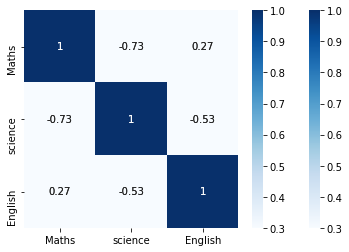

In [12]:
import seaborn as sns 
import matplotlib.pyplot as plt
data={
        "Maths":[60,55,45,40,35],
        "science":[54,34,75,85,69],
        "English":[69,58,29,42,68]
    
}
df=pd.DataFrame(data)
print("-------------------------------------------------------------------------------------------------")
sns.heatmap(df.corr(),annot=True,cbar=True,cmap='Blues',vmin=0.3)



<AxesSubplot:>

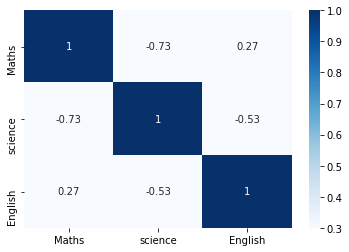

In [13]:
sns.heatmap(df.corr(),annot=True,cbar=True,cmap='Blues',vmin=0.3)


<AxesSubplot:>

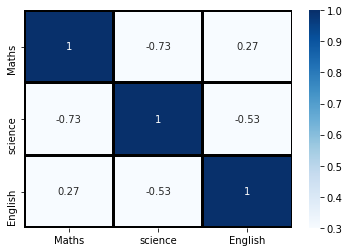

In [19]:
sns.heatmap(df.corr(),annot=True,cbar=True,cmap='Blues',vmin=0.3,linewidths=2,linecolor='black')


In [33]:
data={ "values":[0,40,35,45,32,39,42,100]}
df=pd.DataFrame(data)
print(df)
print("--------------------------------------------------")
print("Q1")
Q1=df['values'].quantile(0.25)
print(Q1)
print("----------------------------------------------")
print("Q3")
Q3=df['values'].quantile(0.75)
print(Q3)
print("-------------------------------------------")
print("IQR")
IQR=Q3-Q1
print(IQR)

   values
0       0
1      40
2      35
3      45
4      32
5      39
6      42
7     100
--------------------------------------------------
Q1
34.25
----------------------------------------------
Q3
42.75
-------------------------------------------
IQR
8.5


In [35]:
print("Lower Bound")
lower_bound=Q1-1.5*IQR
print(lower_bound)
print("--------------------------------------------------------------")
print("Upper Bound")
upper_bound=Q3+1.5*IQR
print(upper_bound)


Lower Bound
21.5
--------------------------------------------------------------
Upper Bound
55.5


In [44]:
outlier=df[(df['values']<lower_bound)|(df['values']>upper_bound)]
print("Outlier")
print(outlier)

Outlier
   values
0       0
7     100


In [45]:
print("Removing Outliers")
clean_df=df[(df['values']>=lower_bound)&df['values']<=upper_bound]
print(clean_df)

   values
0       0
1      40
2      35
3      45
4      32
5      39
6      42
7     100


<AxesSubplot:xlabel='values', ylabel='values'>

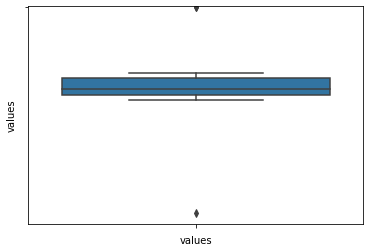

In [52]:
sns.boxplot(data=df ,x=df['values'])
sns.boxplot(data=df ,y=df['values'])

In [58]:
data={
        "Maths":[60,55,45,40,35],
        "science":[54,34,75,85,69],
        "English":[69,2580,29,842,68],
         "Category":["x","y","x","y","x"]
    
}
df=pd.DataFrame(data)

<AxesSubplot:xlabel='Maths', ylabel='science'>

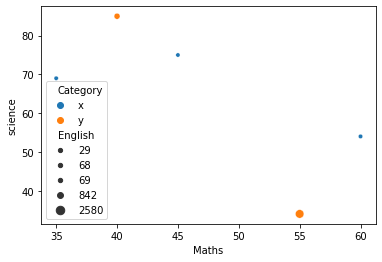

In [59]:
sns.scatterplot(data=df,x=df['Maths'],y=df['science'],hue='Category',size='English')

array([[<AxesSubplot:xlabel='Maths', ylabel='Maths'>,
        <AxesSubplot:xlabel='science', ylabel='Maths'>,
        <AxesSubplot:xlabel='English', ylabel='Maths'>],
       [<AxesSubplot:xlabel='Maths', ylabel='science'>,
        <AxesSubplot:xlabel='science', ylabel='science'>,
        <AxesSubplot:xlabel='English', ylabel='science'>],
       [<AxesSubplot:xlabel='Maths', ylabel='English'>,
        <AxesSubplot:xlabel='science', ylabel='English'>,
        <AxesSubplot:xlabel='English', ylabel='English'>]], dtype=object)

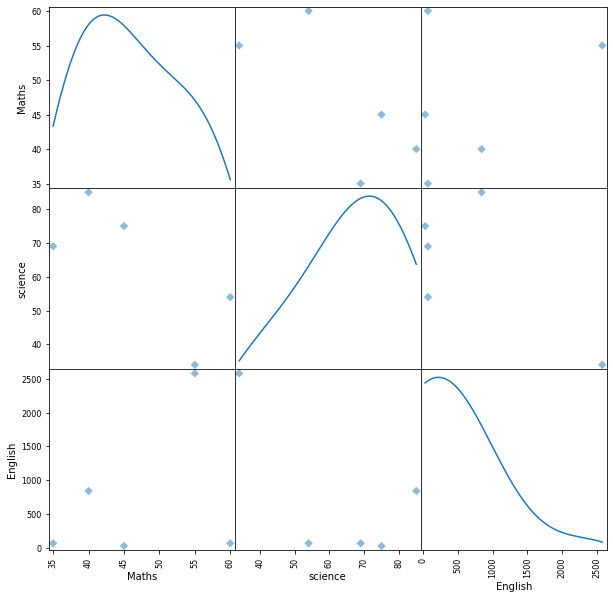

In [63]:
pd.plotting.scatter_matrix(df,figsize=(10,10),marker='D',diagonal="kde")

<AxesSubplot:>

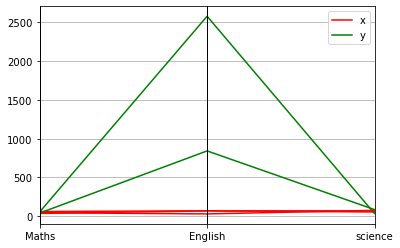

In [65]:
pd.plotting.parallel_coordinates(df,'Category',cols=['Maths','English','science'],color=['red','green'])

In [69]:
data={
        "Maths":[60,55,45,40,35],
        "science":[54,34,75,85,69],
        "English":[69,2580,29,842,68],
         "Category":["x","y","x","y","x"],
          "Gender":["F","M","M","F","F"]
    
}
df=pd.DataFrame(data)


pd.crosstab(df['Gender'],df['Category'],margins=True)

Category,x,y,All
Gender,,,
F,2,1,3
M,1,1,2
All,3,2,5


# Apply

In [75]:
df['total']=df.apply(lambda x:x['Maths']+x['science'],axis=1)
print(df)

   Maths  science  English Category Gender  total
0     60       54       69        x      F    114
1     55       34     2580        y      M     89
2     45       75       29        x      M    120
3     40       85      842        y      F    125
4     35       69       68        x      F    104


In [76]:
df.sum(numeric_only=True)

Maths       235
science     317
English    3588
total       552
dtype: int64

In [78]:
# df.apply(lambda x:'old' if x['Age']>=40 else 'Adult' if x['Age']>18 else child) 

In [80]:
data={"department":["IT","IT","HR","finance","Hr","IT"],
       "Employee":["A","B","C","D","E","F"],
        "Salary":[50000,60000,65000,45000,75000,55000],
         "Experience":[2,4,3,1,4,5]}
df=pd.DataFrame(data)
df.groupby('department')
df.groupby('department').mean(numeric_only=True)
df.groupby(['Salary','Experience']).sum()


,,department,Employee
Salary,Experience,,
45000,1,finance,D
50000,2,IT,A
55000,5,IT,F
60000,4,IT,B
65000,3,HR,C
75000,4,Hr,E
